In [ ]:
#Conexión con drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
#Importar librerías y módulos
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.utils import class_weight
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report,
    mean_absolute_error, mean_squared_error, r2_score
)

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, accuracy_score
import time
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler

import seaborn as sns


# Configuración
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 10)

##Tipos de carga del dataset
Importante: Comentar el que no se use.

In [ ]:
#Dataframe con subida de archivo
#df = pd.read_csv('dataset_elpino.csv', sep=";", encoding="utf-8")
#df.head()

In [ ]:
#Dataframe con drive
df = pd.read_csv('/content/drive/MyDrive/Proyectos_Universidad/Aprendizaje_de_Maquina/dataset/dataset_elpino.csv', sep=";", encoding="utf-8")
df.head()

,Diag 01 Principal (cod+des),Diag 02 Secundario (cod+des),Diag 03 Secundario (cod+des),Diag 04 Secundario (cod+des),Diag 05 Secundario (cod+des),Diag 06 Secundario (cod+des),Diag 07 Secundario (cod+des),Diag 08 Secundario (cod+des),Diag 09 Secundario (cod+des),Diag 10 Secundario (cod+des),Diag 11 Secundario (cod+des),Diag 12 Secundario (cod+des),Diag 13 Secundario (cod+des),Diag 14 Secundario (cod+des),Diag 15 Secundario (cod+des),Diag 16 Secundario (cod+des),Diag 17 Secundario (cod+des),Diag 18 Secundario (cod+des),Diag 19 Secundario (cod+des),Diag 20 Secundario (cod+des),Diag 21 Secundario (cod+des),Diag 22 Secundario (cod+des),Diag 23 Secundario (cod+des),Diag 24 Secundario (cod+des),Diag 25 Secundario (cod+des),Diag 26 Secundario (cod+des),Diag 27 Secundario (cod+des),Diag 28 Secundario (cod+des),Diag 29 Secundario (cod+des),Diag 30 Secundario (cod+des),Diag 31 Secundario (cod+des),Diag 32 Secundario (cod+des),Diag 33 Secundario (cod+des),Diag 34 Secundario (cod+des),Diag 35 Secundario (cod+des),Proced 01 Principal (cod+des),Proced 02 Secundario (cod+des),Proced 03 Secundario (cod+des),Proced 04 Secundario (cod+des),Proced 05 Secundario (cod+des),Proced 06 Secundario (cod+des),Proced 07 Secundario (cod+des),Proced 08 Secundario (cod+des),Proced 09 Secundario (cod+des),Proced 10 Secundario (cod+des),Proced 11 Secundario (cod+des),Proced 12 Secundario (cod+des),Proced 13 Secundario (cod+des),Proced 14 Secundario (cod+des),Proced 15 Secundario (cod+des),Proced 16 Secundario (cod+des),Proced 17 Secundario (cod+des),Proced 18 Secundario (cod+des),Proced 19 Secundario (cod+des),Proced 20 Secundario (cod+des),Proced 21 Secundario (cod+des),Proced 22 Secundario (cod+des),Proced 23 Secundario (cod+des),Proced 24 Secundario (cod+des),Proced 25 Secundario (cod+des),Proced 26 Secundario (cod+des),Proced 27 Secundario (cod+des),Proced 28 Secundario (cod+des),Proced 29 Secundario (cod+des),Proced 30 Secundario (cod+des),Edad en años,Sexo (Desc),GRD
0,A41.8 - Otras septicemias especificadas,B37.6 - Endocarditis debida a candida (I39.8*),"I39.8 - Endocarditis, válvula no especificada,...",N10 - Nefritis tubulointersticial aguda,B96.1 - Klebsiella pneumoniae [K. pneumoniae] ...,L89.9 - Úlcera de decúbito y area de presión n...,L08.9 - Infección local de la piel y del tejid...,B96.2 - Escherichia coli [E. coli] como causa ...,A41.5 - Sepsis por otros organnismos Gram nega...,J86.9 - Piotórax sin fístula,"U07.1 - COVID-19, virus identificado",Y95 - Afección nosocomial,"N18.5 - Enfermedad renal crónica, estadio 5",E87.1 - Hiposmolaridad e hiponatremia,D64.9 - Anemia de tipo no especificado,"G82.2 - Paraplejía, no especificada","N31.9 - Disfunción neuromuscular de la vejiga,...",I10 - Hipertensión esencial (primaria),K70.4 - Insuficiencia hepática alcohólica,F19.2 - Trastornos mentales y del comportamien...,F10.2 - Trastornos mentales y del comportamien...,"E46 - Desnutrición proteicocalórica, no especi...","G40.9 - Epilepsia, tipo no especificado","L21.9 - Dermatitis seborreica, no especificada",Z93.5 - Cistostomía,Z93.3 - Colostomía,Z99.2 - Dependencia de diálisis renal,Z91.6 - Historia personal de otro trauma físico,-,-,-,-,-,-,-,"86.28 - DESBRIDAMIENTO HERIDA,INFECCION O QUEM...",34.91 - TORACOCENTESIS,88.38 - TOMOGRAFIA AXIAL COMPUTERIZADA OTRA,87.41 - TOMOGRAFIA AXIAL COMPUTERIZADA TORAX,88.75 - ECOGRAFIA APARATO URINARIO,88.01 - TOMOGRAFIA AXIAL COMPUTERIZADA ABDOMEN,88.43 - ARTERIOGRAFIA ARTERIA PULMONAR,88.41 - ARTERIOGRAFIA ARTERIA CEREBRAL,87.44 - RADIOGRAFIA TORAX RUTINARIA,99.29 - INYECCION SUSTANCIA TERAPEUTICA O PROF...,99.19 - INYECCION ANTICOAGULANTE,99.18 - INYECCION ELECTROLITO,99.21 - INYECCION ANTIBIOTICO,99.26 - INYECCION TRANQUILIZANTE,99.23 - INYECCION ESTEROIDE,93.94 - AEROSOLTERAPIA,89.52 - ELECTROCARDIOGRAFIA,90.59 - EXAMEN MICROSCOPICO SANGRE.OTRO,89.65 - GASOMETRIA ARTERIA,39.95 - HEMODIALISIS,39.95 - HEMODIALISIS,99.04 - TRANSFUSION CONCENTRADO HEMATIES,90.39 - EXAMEN MICROSCOPICO ORL.OTRO,99.84 - AISLAMIENTO,88.7

In [ ]:
# Dimensiones del dataset
print("Shape del dataset:", df.shape)

# Nombres de columnas
print("\nColumnas:")
print(df.columns.tolist())

# Tipos de datos
print("\nTipos de datos:")
print(df.dtypes)

# Valores nulos
print("\nValores nulos:")
print(df.isnull().sum())

#Edad promedio hombres vs mujeres
print("Edad promedio por sexo:")
df["Edad en años"].groupby(df["Sexo (Desc)"]).mean()

Shape del dataset: (14561, 68)

Columnas:
['Diag 01 Principal (cod+des)', 'Diag 02 Secundario (cod+des)', 'Diag 03 Secundario (cod+des)', 'Diag 04 Secundario (cod+des)', 'Diag 05 Secundario (cod+des)', 'Diag 06 Secundario (cod+des)', 'Diag 07 Secundario (cod+des)', 'Diag 08 Secundario (cod+des)', 'Diag 09 Secundario (cod+des)', 'Diag 10 Secundario (cod+des)', 'Diag 11 Secundario (cod+des)', 'Diag 12 Secundario (cod+des)', 'Diag 13 Secundario (cod+des)', 'Diag 14 Secundario (cod+des)', 'Diag 15 Secundario (cod+des)', 'Diag 16 Secundario (cod+des)', 'Diag 17 Secundario (cod+des)', 'Diag 18 Secundario (cod+des)', 'Diag 19 Secundario (cod+des)', 'Diag 20 Secundario (cod+des)', 'Diag 21 Secundario (cod+des)', 'Diag 22 Secundario (cod+des)', 'Diag 23 Secundario (cod+des)', 'Diag 24 Secundario (cod+des)', 'Diag 25 Secundario (cod+des)', 'Diag 26 Secundario (cod+des)', 'Diag 27 Secundario (cod+des)', 'Diag 28 Secundario (cod+des)', 'Diag 29 Secundario (cod+des)', 'Diag 30 Secundario (cod+des)'

,Edad en años
Sexo (Desc),
Hombre,43.604976
Mujer,37.278465


In [ ]:
# Número de clases únicas
num_clases = df["GRD"].nunique()
print("Número de clases (GRD):", num_clases)

# Conteo de ejemplos por clase
class_counts = df["GRD"].value_counts()

print("\nTop 10 clases más frecuentes:")
print(class_counts.head(10))

print("\nClases menos frecuentes:")
print(class_counts.tail(10))

Número de clases (GRD): 526

Top 10 clases más frecuentes:
GRD
146101 - PH CESÁREA                                                                       813
146121 - PH PARTO VAGINAL CON PROCED., EXCEPTO ESTERILIZACIÓN Y/O DILATACIÓN Y LEGRADO    639
146131 - PH PARTO VAGINAL                                                                 538
158171 - MH NEONATO, PESO AL NACER >2499 GR SIN PROCEDIMIENTO MAYOR                       389
134161 - MH TRASTORNOS DEL ANTEPARTO                                                      325
071141 - PH COLECISTECTOMÍA LAPAROSCÓPICA                                                 317
044153 - MH INFECCIONES E INFLAMACIONES RESPIRATORIAS W/MCC                               287
061131 - PH PROCEDIMIENTOS SOBRE APÉNDICE                                                 252
041023 - PH VENTILACIÓN MECÁNICA PROLONGADA SIN TRAQUEOSTOMÍA W/MCC                       248
146102 - PH CESÁREA W/CC                                                                  2

In [ ]:
# =========================================
# 1. EXTRAER SOLO CÓDIGO DE GRD
# =========================================
df["GRD_codigo"] = df["GRD"].apply(lambda x: str(x).split(" - ")[0])

# =========================================
# 2. SELECCIONAR TOP 30 CLASES
# =========================================
top_n = 30

top_classes = df["GRD_codigo"].value_counts().head(top_n).index

df = df[df["GRD_codigo"].isin(top_classes)].copy()

print("Nuevo número de clases:", df["GRD_codigo"].nunique())
print("Nuevo tamaño dataset:", df.shape)

# =========================================
# 3. LIMPIAR DIAGNÓSTICOS (dejando solo códigos)
# =========================================
diag_cols = [col for col in df.columns if "Diag" in col]

def limpiar_codigos(row):
    codigos = []
    for col in diag_cols:
        val = str(row[col])
        if val != "-" and val != "nan":
            codigo = val.split(" - ")[0]
            codigos.append(codigo)
    return " ".join(codigos)

df["Diagnosticos"] = df.apply(limpiar_codigos, axis=1)

# =========================================
# 4. LIMPIAR PROCEDIMIENTOS (dejando solo códigos)
# =========================================
proc_cols = [col for col in df.columns if "Proced" in col]

def limpiar_procedimientos(row):
    codigos = []
    for col in proc_cols:
        val = str(row[col])
        if val != "-" and val != "nan":
            codigo = val.split(" - ")[0]
            codigos.append(codigo)
    return " ".join(codigos)

df["Procedimientos"] = df.apply(limpiar_procedimientos, axis=1)

# =========================================
# 5. BINARIZAR SEXO
# =========================================
df["Sexo_binario"] = df["Sexo (Desc)"].map({
    "Hombre": 1,
    "Mujer": 0
})

# =========================================
# 6. PREPARAR VARIABLES FINALES
# =========================================
X_text_diag = df["Diagnosticos"]
X_text_proc = df["Procedimientos"]
X_edad = df["Edad en años"]
X_sexo = df["Sexo_binario"]

y = df["GRD_codigo"]

# =========================================
# 7. COUNT VECTORIZER (DIAGNÓSTICOS)
# =========================================
from sklearn.feature_extraction.text import CountVectorizer

vectorizer_diag = CountVectorizer()
X_diag = vectorizer_diag.fit_transform(X_text_diag)

# =========================================
# 8. COUNT VECTORIZER (PROCEDIMIENTOS)
# =========================================
vectorizer_proc = CountVectorizer()
X_proc = vectorizer_proc.fit_transform(X_text_proc)

# =========================================
# 9. COMBINAR TODO
# =========================================
from scipy.sparse import hstack

X = hstack([X_diag, X_proc])

# Agregar edad y sexo
import numpy as np

X_extra = np.array([X_edad, X_sexo]).T

from scipy.sparse import csr_matrix

X = hstack([X, csr_matrix(X_extra)])

print("Shape final de X:", X.shape)
print("Número de clases:", y.nunique())
df.head()

Nuevo número de clases: 30
Nuevo tamaño dataset: (7106, 69)
Shape final de X: (7106, 1135)
Número de clases: 30


,Diag 01 Principal (cod+des),Diag 02 Secundario (cod+des),Diag 03 Secundario (cod+des),Diag 04 Secundario (cod+des),Diag 05 Secundario (cod+des),Diag 06 Secundario (cod+des),Diag 07 Secundario (cod+des),Diag 08 Secundario (cod+des),Diag 09 Secundario (cod+des),Diag 10 Secundario (cod+des),Diag 11 Secundario (cod+des),Diag 12 Secundario (cod+des),Diag 13 Secundario (cod+des),Diag 14 Secundario (cod+des),Diag 15 Secundario (cod+des),Diag 16 Secundario (cod+des),Diag 17 Secundario (cod+des),Diag 18 Secundario (cod+des),Diag 19 Secundario (cod+des),Diag 20 Secundario (cod+des),Diag 21 Secundario (cod+des),Diag 22 Secundario (cod+des),Diag 23 Secundario (cod+des),Diag 24 Secundario (cod+des),Diag 25 Secundario (cod+des),Diag 26 Secundario (cod+des),Diag 27 Secundario (cod+des),Diag 28 Secundario (cod+des),Diag 29 Secundario (cod+des),Diag 30 Secundario (cod+des),Diag 31 Secundario (cod+des),Diag 32 Secundario (cod+des),Diag 33 Secundario (cod+des),Diag 34 Secundario (cod+des),Diag 35 Secundario (cod+des),Proced 01 Principal (cod+des),Proced 02 Secundario (cod+des),Proced 03 Secundario (cod+des),Proced 04 Secundario (cod+des),Proced 05 Secundario (cod+des),Proced 06 Secundario (cod+des),Proced 07 Secundario (cod+des),Proced 08 Secundario (cod+des),Proced 09 Secundario (cod+des),Proced 10 Secundario (cod+des),Proced 11 Secundario (cod+des),Proced 12 Secundario (cod+des),Proced 13 Secundario (cod+des),Proced 14 Secundario (cod+des),Proced 15 Secundario (cod+des),Proced 16 Secundario (cod+des),Proced 17 Secundario (cod+des),Proced 18 Secundario (cod+des),Proced 19 Secundario (cod+des),Proced 20 Secundario (cod+des),Proced 21 Secundario (cod+des),Proced 22 Secundario (cod+des),Proced 23 Secundario (cod+des),Proced 24 Secundario (cod+des),Proced 25 Secundario (cod+des),Proced 26 Secundario (cod+des),Proced 27 Secundario (cod+des),Proced 28 Secundario (cod+des),Proced 29 Secundario (cod+des),Proced 30 Secundario (cod+des),Edad en años,Sexo (Desc),GRD,GRD_codigo,Diagnosticos,Procedimientos,Sexo_binario
3,K76.8 - Otras enfermedades especificadas del h...,K66.1 - Hemoperitoneo,"N18.5 - Enfermedad renal crónica, estadio 5",D64.9 - Anemia de tipo no especificado,E87.5 - Hiperpotasemia,E87.2 - Acidosis,J81 - Edema pulmonar,N17.8 - Otras insuficiencias renales agudas,J44.9 - Enfermedad pulmonar obstructiva crónic...,R41.0 - Desorientación no especificada,K44.9 - Hernia diafragmática sin obstrucción n...,"K26.9 - Úlcera duodenal, no especificada como ...",B96.2 - Escherichia coli [E. coli] como causa ...,R57.1 - Choque hipovolémico,K80.2 - Cálculo de la vesícula biliar sin cole...,L89.0 - Úlcera de decúbito y area de presión e...,F12.2 - Trastornos mentales y del comportamien...,Z91.1 - Historia personal de incumplimiento de...,Z99.2 - Dependencia de diálisis renal,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,54.19 - LAPAROTOMIA.OTRA,39.98 - CONTROL HEMORRAGIA NEOM,"86.28 - DESBRIDAMIENTO HERIDA,INFECCION O QUEM...",54.62 - CIERRE DIFERIDO HERIDA ABDOMEN EN GRAN...,96.72 - VENTILACION MECANICA CONTINUA OTRA.DUR...,96.04 - INTUBACION ENDOTRAQUEAL,87.41 - TOMOGRAFIA AXIAL COMPUTERIZADA TORAX,88.01 - TOMOGRAFIA AXIAL COMPUTERIZADA ABDOMEN,88.38 - TOMOGRAFIA AXIAL COMPUTERIZADA OTRA,88.41 - ARTERIOGRAFIA ARTERIA CEREBRAL,88.47 - ARTERIOGRAFIA ARTERIA INTRABDOMINAL OTRA,87.44 - RADIOGRAFIA TORAX RUTINARIA,88.75 - ECOGRAFIA APARATO URINARIO,88.79 - ECOGRAFIA OTRA,88.72 - ECOCARDIOGRAFIA,89.52 - ELECTROCARDIOGRAFIA,45.13 - ESOFAGOGASTRODUODENOSCOPIA [EGD],38.93 - CATETERISMO VENA OTRO,38.91 - CATETERISMO ARTERIA,38.95 - CATETERISMO VENA PARA DIALISIS RIÑON,39.95 - HEMODIALISIS,96.59 - IRRIGACION HERIDA OTRA,94.19 - ENTREVISTA Y EVALUACION PSIQUIATRICA.OTRA,57.94 - SONDAJE URINARIO PERMANENTE,00.13 - INYECCION NESIRITIDE,00.17 - INFUSON AGENTE VASOPRESOR,99.04 - TRANSFUSION CONCENTRADO HEMATIES,99.18 - INYECCION ELECTROLITO,99.21 - INYECCION ANTIBIOTICO,99.23 - INYECCION ESTEROIDE,61,Hombre,041023 - PH VENTILACIÓN MECÁNICA PROLONGADA SI...,041023,K76.8 K66.1 N18.5 D6

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

#X_train, X_test, y_train, y_test = train_test_split(
 #   X,
   # y,
  #  test_size=0.2,        # 20% para test
   # random_state=42,      # Reproducibilidad
    #stratify=y            # Mantener proporción de clases
#)

# =========================================
# VERIFICACIÓN
# =========================================
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

print("\nDistribución clases en TRAIN:")
print(y_train.value_counts(normalize=True).head())

print("\nDistribución clases en TEST:")
print(y_test.value_counts(normalize=True).head())

Train shape: (5684, 1135)
Test shape: (1422, 1135)

Distribución clases en TRAIN:
GRD_codigo
146101    0.114356
146121    0.089901
146131    0.075651
158171    0.054715
134161    0.045742
Name: proportion, dtype: float64

Distribución clases en TEST:
GRD_codigo
146101    0.114627
146121    0.090014
146131    0.075949
158171    0.054852
134161    0.045710
Name: proportion, dtype: float64


In [ ]:
# =========================================
# 2. CODIFICAR ETIQUETAS (GRD)
# =========================================
le = LabelEncoder()

y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

num_classes = len(le.classes_)

##DESDE AQUÍ SON LOS INTENTOS DE RANDOM FOREST
Primero hice uno normal y con ese saqué las 76 variables que explican el 90% del problema, esas variables las usé para entrenar un moderlo (este que viene y dice  Entrenamiento del modelo con el set de variables reducido), resultados: una caca, no logra pasar del 80% ni si quiera en accuracy, menos f1, tanto sacando o dejando el class weight (castiga dinamicamente los errores de predicción dependiendo de si es clase minoritaria o no).

In [ ]:
# Train reducido
# 1. Definir lista de variables
variables_90 = ['o70', '69', '75', 'z39', '74', 'z37', 'o82', '73', 'z38', 'Edad en años', '57', '24', 'o80', '94', '34', '59', '51', '47', '87', '26', 'k35', '03', '99', '96', '93', 'u07', '97', 'j96', 'o34', '64', '23', '44', '72', '91', 'k80', 'z29', '29', 'j12', '90', '19', '39', '01', '86', 'z01', '04', 'z76', '88', 'r06', 'o99', '00', 'i50', 'p59', '78', '41', '38', 's00', '65', 'o68', '52', '18', 'o60', '68', 'z92', 's06', 'j21', 'j20', '09', '83', '21', '71', '89', 'e88', '17', 'Sexo_binario', '12', 'i10']

# 2. Obtener los índices numéricos correspondientes a esos nombres
# feature_names fue definida previamente como la lista completa de columnas de X
indices_90 = [feature_names.index(var) for var in variables_90]

# 3. Filtrar la matriz dispersa usando los índices (X[:, indices])
X_train_reducido = X_train[:, indices_90]
X_test_reducido = X_test[:, indices_90]

print("Nuevo shape Train:", X_train_reducido.shape)
print("Nuevo shape Test:", X_test_reducido.shape)

NameError: name 'feature_names' is not defined

In [ ]:
# Entrenamiento del modelo con el set de variables reducido (90% importancia)
modelo_rf_reducido = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_leaf=3,
    random_state=42,
    class_weight=class_weights  # se puede quitar o poner el class weight
)

# Ajustar el modelo con los datos reducidos
modelo_rf_reducido.fit(X_train_reducido, y_train_enc)

# Predicciones
pred_reducido = modelo_rf_reducido.predict(X_test_reducido)

# Evaluación
print("Reporte de Clasificación - Modelo Reducido (76 variables):")
print(classification_report(y_test_enc, pred_reducido, target_names=le.classes_))

NameError: name 'class_weights' is not defined

##Entrenamiento con todas las variables
Por lo visto, por la naturaleza de random forest (busqueda de árbol) el tener muchas variables no necesariamente hace que este sea malo, como que esto ayuda a que el modelo llegue a encontrar esos detalles para poder clasificar bien los grd tomando info de las variables del 10% restante anterior (las más de 1000 que quedaban al separar las 76 en el modelo anterior).
Ojo que aquí sí o sí se debe utilizar con el class weight, puesto que esto hace que no haya clases con 0% de alguna métrica (si comentan o quitan el class weight podrán ver este fenómeno, influenciado por la pereza que le da al modelo tener que predecir estas clases minoritarias que terminan siendo devoradas por clases más grandes)

In [ ]:
class_weights = class_weight.compute_class_weight(class_weight='balanced', classes=np.unique(y_train_enc), y=y_train_enc)
class_weights_dict = dict(enumerate(class_weights))

modelo_rf_b = RandomForestClassifier(n_estimators=200, max_depth=8, min_samples_leaf=3, random_state=42,class_weight=class_weights_dict ) # se puede quitar o poner el class weight
modelo_rf_b.fit(X_train, y_train_enc)
pred_b = modelo_rf_b.predict(X_test)
print(classification_report(y_test_enc, pred_b))

              precision    recall  f1-score   support

           0       0.92      0.92      0.92        24
           1       0.88      0.98      0.92        50
           2       0.88      0.88      0.88        26
           3       0.93      0.89      0.91        57
           4       0.85      0.37      0.52        46
           5       0.73      0.93      0.82        29
           6       0.61      0.70      0.66        27
           7       0.65      0.90      0.76        41
           8       0.96      1.00      0.98        50
           9       0.76      0.94      0.84        31
          10       0.85      0.52      0.65        21
          11       0.92      0.71      0.80        63
          12       0.57      0.88      0.70        26
          13       0.88      1.00      0.94        23
          14       0.86      0.70      0.78        27
          15       0.81      0.93      0.86        27
          16       0.59      0.43      0.50        23
          17       0.94    

##Ahora vienen los gráficos y matrices, etc

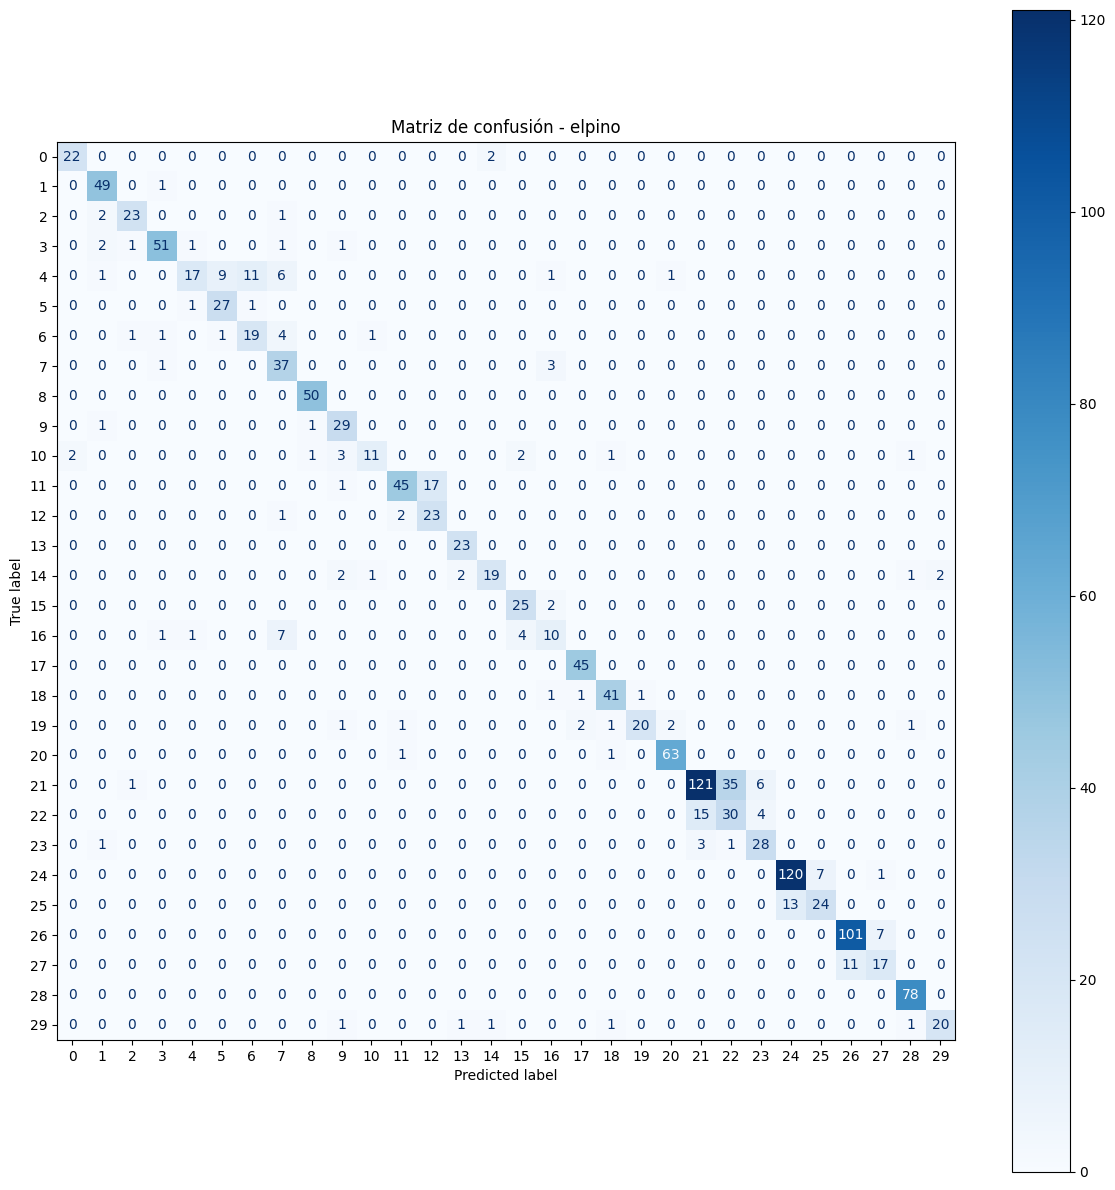

In [ ]:
cm_b = confusion_matrix(y_test_enc, pred_b, labels=modelo_rf_b.classes_)
fig, ax = plt.subplots(figsize=(12, 12))  # Se aumenta el tamaño para dar más espacio
ConfusionMatrixDisplay(confusion_matrix=cm_b, display_labels=modelo_rf_b.classes_).plot(ax=ax, cmap='Blues')
plt.title('Matriz de confusión - elpino')
plt.tight_layout()  # Ajusta los elementos para que no se amontonen
plt.show()

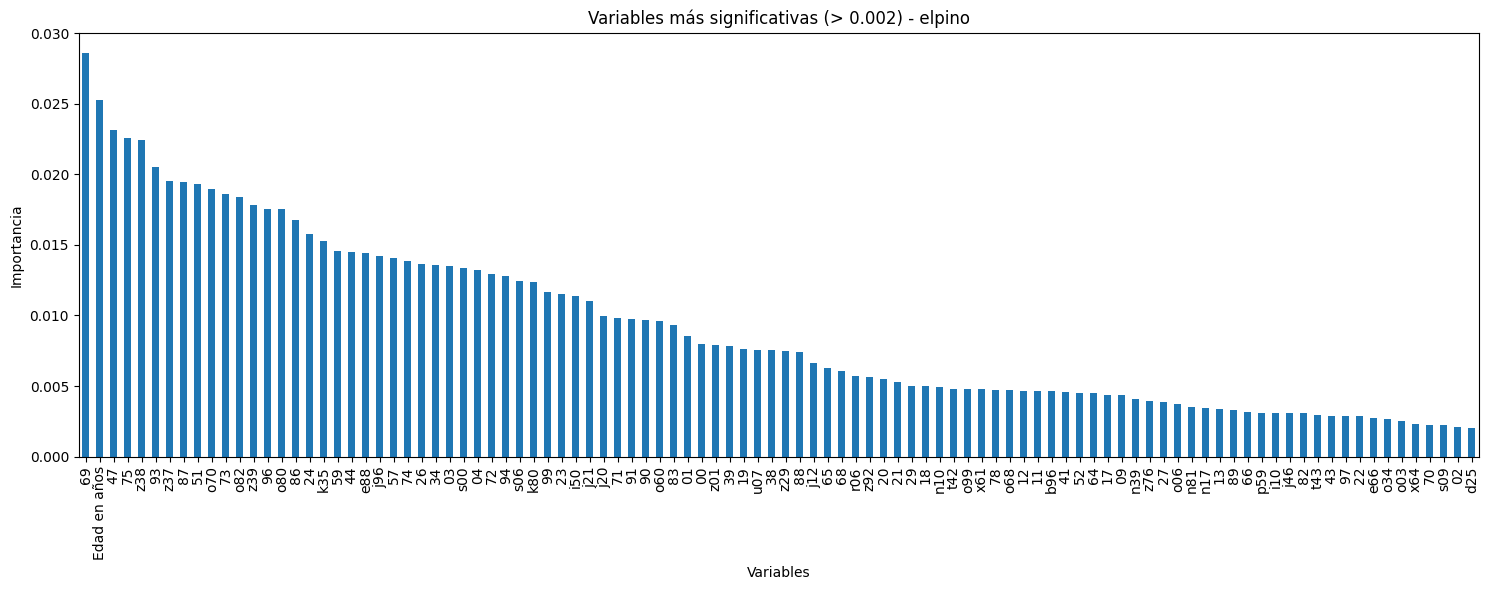

In [ ]:
feature_names = vectorizer_diag.get_feature_names_out().tolist() + \
                vectorizer_proc.get_feature_names_out().tolist() + \
                ['Edad en años', 'Sexo_binario']

importancias = pd.Series(modelo_rf_b.feature_importances_, index=feature_names).sort_values(ascending=False)

# Filtrar variables con importancia > 0.002
importancias_filtradas = importancias[importancias > 0.002]

importancias_filtradas.plot(kind='bar', figsize=(15, 6))
plt.title('Variables más significativas (> 0.002) - elpino')
plt.ylabel('Importancia')
plt.xlabel('Variables')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt

# Encontrar los valores de X para 0.8 y 0.9
x_80 = (importancia_acumulada >= 0.80).idxmax()
x_idx_80 = importancia_acumulada.index.get_loc(x_80) + 1

x_90 = (importancia_acumulada >= 0.90).idxmax()
x_idx_90 = importancia_acumulada.index.get_loc(x_90) + 1

# Curva para encontrar las variables con significancia en el modelo
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(importancia_acumulada) + 1), importancia_acumulada, marker='o', linestyle='--', markersize=2)

# Líneas para 80%
plt.axhline(y=0.80, color='r', linestyle='-', label=f'80% Importancia ({x_idx_80} var)')
plt.axvline(x=x_idx_80, color='r', linestyle=':')

# Líneas para 90%
plt.axhline(y=0.90, color='g', linestyle='-', label=f'90% Importancia ({x_idx_90} var)')
plt.axvline(x=x_idx_90, color='g', linestyle=':')

# Etiquetas de texto en el eje X
plt.text(x_idx_80, 0.5, f'X={x_idx_80}', color='red', fontweight='bold', ha='right')
plt.text(x_idx_90, 0.4, f'X={x_idx_90}', color='green', fontweight='bold', ha='right')

plt.title('Curva de Importancia Acumulada con Intersecciones')
plt.xlabel('Número de Variables')
plt.ylabel('Importancia Total')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()
#resultados:
#80% = 53 ; 90% = 76 variables

NameError: name 'importancia_acumulada' is not defined

#Estos dos son los códigos que usé para sacar los mejores 76
Lo mejor sería no usarlos de nuevo porque igual y cambian, por eso los comentaré.

In [ ]:
# Extraer los nombres de las 76 variables (90% de importancia)
'''
top_76_vars = importancia_acumulada.head(x_idx_90).index.tolist()

print(f"Las {x_idx_90} variables que componen el 90% de la importancia son:")
print(top_76_vars)
'''

'\ntop_76_vars = importancia_acumulada.head(x_idx_90).index.tolist()\n\nprint(f"Las {x_idx_90} variables que componen el 90% de la importancia son:")\nprint(top_76_vars)\n'

In [ ]:
# Mostrar en un formato más legible (DataFrame)
# Aseguramos que los nombres sean únicos si existen duplicados en el vectorizador
'''
top_76_vars_unique = []
for v in top_76_vars:
    if v not in top_76_vars_unique:
        top_76_vars_unique.append(v)

# Limitamos a las primeras 76 variables únicas para mantener la consistencia con el análisis
top_76_vars_unique = top_76_vars_unique[:76]

top_76_importancias = importancias.iloc[:76]
top_76_acumulada = importancia_acumulada.iloc[:76]

top_vars_df = pd.DataFrame({
    'Variable': top_76_importancias.index,
    'Importancia': top_76_importancias.values,
    'Acumulada': top_76_acumulada.values
})

pd.set_option('display.max_rows', 80)
display(top_vars_df)
'''

"\ntop_76_vars_unique = []\nfor v in top_76_vars:\n    if v not in top_76_vars_unique:\n        top_76_vars_unique.append(v)\n\n# Limitamos a las primeras 76 variables únicas para mantener la consistencia con el análisis\ntop_76_vars_unique = top_76_vars_unique[:76]\n\ntop_76_importancias = importancias.iloc[:76]\ntop_76_acumulada = importancia_acumulada.iloc[:76]\n\ntop_vars_df = pd.DataFrame({\n    'Variable': top_76_importancias.index,\n    'Importancia': top_76_importancias.values,\n    'Acumulada': top_76_acumulada.values\n})\n\npd.set_option('display.max_rows', 80)\ndisplay(top_vars_df)\n"

##ESTOS SON LOS 10 MODELOS TENIENDO DE BASE EL CLASS WEIGTHT Y LA SEMILLA 42 (CREO QUE HAY QUE RANDOMIZARLA PERO ME MUERO DE SUEÑO Y NO LA QUIERO CAGAR XD)
me faltan gráficos para el mejor de estos 10, pero con pedirle a gemini los de curvas ROC por grd y promedios globales, matriz de confucion, evolución de loss, evolución de accuracy y de f1, creo que sería? porque son los que se usaron en el mlp, el de f1 no pero es necesario para el análisis de este modelo random forest

In [ ]:
# =========================================
# 10 VARIACIONES DE RANDOM FOREST CON MÉTRICAS COMPLETAS
# =========================================
import pandas as pd
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import classification_report
import time

# Definimos 10 configuraciones diferentes para Random Forest
variaciones_rf = [
    {"nombre": "RF 1 (Base)", "n_estimators": 200, "max_depth": 8, "min_samples_leaf": 3},
    {"nombre": "RF 2 (Más árboles)", "n_estimators": 500, "max_depth": 8, "min_samples_leaf": 3},
    {"nombre": "RF 3 (Más profundo)", "n_estimators": 200, "max_depth": 15, "min_samples_leaf": 2},
    {"nombre": "RF 4 (Libre + Hojas 4)", "n_estimators": 300, "max_depth": None, "min_samples_leaf": 4},
    {"nombre": "RF 5 (Agresivo)", "n_estimators": 300, "max_depth": None, "min_samples_leaf": 1},
    {"nombre": "RF 6 (Shallow forest)", "n_estimators": 800, "max_depth": 5, "min_samples_leaf": 2},
    {"nombre": "RF 7 (Rápido)", "n_estimators": 100, "max_depth": 10, "min_samples_leaf": 2},
    {"nombre": "RF 8 (Alta generalización)", "n_estimators": 200, "max_depth": 12, "min_samples_leaf": 6},
    {"nombre": "RF 9 (Max features None)", "n_estimators": 200, "max_depth": 10, "min_samples_leaf": 2, "max_features": None},
    {"nombre": "RF 10 (Heavy duty)", "n_estimators": 600, "max_depth": 20, "min_samples_leaf": 2}
]

resultados_rf = []

for var in variaciones_rf:
    params = {k: v for k, v in var.items() if k != 'nombre'}

    print(f"\nEntrenando {var['nombre']} | árboles: {params.get('n_estimators')} | Profundidad: {params.get('max_depth')} | Hojas: {params.get('min_samples_leaf')}")

    # CORRECCIÓN: Se usa class_weights_dict (diccionario) en lugar de class_weights (array)
    modelo_rf = RandomForestClassifier(
        random_state=42,
        class_weight=class_weights_dict,
        n_jobs=-1,
        **params
    )

    modelo_rf.fit(X_train, y_train_enc)
    y_pred_rf = modelo_rf.predict(X_test)

   #Extraer TODAS las métricas como diccionario
    reporte = classification_report(y_test_enc, y_pred_rf, output_dict=True, zero_division=0)

    #Guardar métricas específicas
    acc = reporte['accuracy']

    macro_prec = reporte['macro avg']['precision']
    macro_rec = reporte['macro avg']['recall']
    macro_f1 = reporte['macro avg']['f1-score']

    weight_prec = reporte['weighted avg']['precision']
    weight_rec = reporte['weighted avg']['recall']
    weight_f1 = reporte['weighted avg']['f1-score']

    #Agregar a la lista de resultados
    resultados_rf.append({
        "Modelo": var['nombre'],
        "Accuracy": round(acc, 4),
        "Macro Prec": round(macro_prec, 4),
        "Macro Recall": round(macro_rec, 4),
        "Macro F1": round(macro_f1, 4),
        "Weighted Prec": round(weight_prec, 4),
        "Weighted Recall": round(weight_rec, 4),
        "Weighted F1": round(weight_f1, 4)
    })
    print(f"-> Listo. Accuracy: {acc:.4f} | Macro F1: {macro_f1:.4f}")

# =========================================
# MOSTRAR TABLA FINAL DE RESULTADOS
# =========================================
print("\n=== RESUMEN DETALLADO DE LAS 10 VARIACIONES DE RANDOM FOREST ===")
# Convertir a DataFrame y ordenar por Macro F1 de mayor a menor (¡Mucho mejor que por Accuracy!)
resumen_rf_df = pd.DataFrame(resultados_rf).sort_values(by="Macro F1", ascending=False)

# Mostrar la tabla en Colab
display(resumen_rf_df)


Entrenando RF 1 (Base) | árboles: 200 | Profundidad: 8 | Hojas: 3
-> Listo. Accuracy: 0.8354 | Macro F1: 0.8072

Entrenando RF 2 (Más árboles) | árboles: 500 | Profundidad: 8 | Hojas: 3
-> Listo. Accuracy: 0.8397 | Macro F1: 0.8106

Entrenando RF 3 (Más profundo) | árboles: 200 | Profundidad: 15 | Hojas: 2
-> Listo. Accuracy: 0.8601 | Macro F1: 0.8333

Entrenando RF 4 (Libre + Hojas 4) | árboles: 300 | Profundidad: None | Hojas: 4
-> Listo. Accuracy: 0.8537 | Macro F1: 0.8296

Entrenando RF 5 (Agresivo) | árboles: 300 | Profundidad: None | Hojas: 1
-> Listo. Accuracy: 0.8530 | Macro F1: 0.8022

Entrenando RF 6 (Shallow forest) | árboles: 800 | Profundidad: 5 | Hojas: 2
-> Listo. Accuracy: 0.8214 | Macro F1: 0.7936

Entrenando RF 7 (Rápido) | árboles: 100 | Profundidad: 10 | Hojas: 2
-> Listo. Accuracy: 0.8453 | Macro F1: 0.8148

Entrenando RF 8 (Alta generalización) | árboles: 200 | Profundidad: 12 | Hojas: 6
-> Listo. Accuracy: 0.8411 | Macro F1: 0.8160

Entrenando RF 9 (Max features

,Modelo,Accuracy,Macro Prec,Macro Recall,Macro F1,Weighted Prec,Weighted Recall,Weighted F1
9,RF 10 (Heavy duty),0.8713,0.8578,0.8439,0.8455,0.8725,0.8713,0.8680
2,RF 3 (Más profundo),0.8601,0.8433,0.8344,0.8333,0.8624,0.8601,0.8569
3,RF 4 (Libre + Hojas 4),0.8537,0.8360,0.8364,0.8296,0.8603,0.8537,0.8515
7,RF 8 (Alta generalización),0.8411,0.8236,0.8257,0.8160,0.8501,0.8411,0.8385
6,RF 7 (Rápido),0.8453,0.8254,0.8224,0.8148,0.8544,0.8453,0.8424
1,RF 2 (Más árboles),0.8397,0.8204,0.8188,0.8106,0.8482,0.8397,0.8368
0,RF 1 (Base),0.8354,0.8196,0.8151,0.8072,0.8462,0.8354,0.8325
4,RF 5 (Agresivo),0.8530,0.8869,0.7913,0.8022,0.8627,0.8530,0.8288
5,RF 6 (Shallow forest),0.8214,0.8110,0.8075,0.7936,0.8392,0.8214,0.8172
8,RF 9 (Max features None),0.8235,0.8032,0.7735,0.7695,0.8420,0.8235,0.8203


##El mejor de random forest (que me salió):

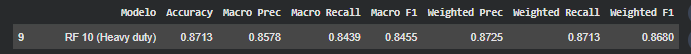

##Acá abajo está una foto del mejor de mlp, para comparar


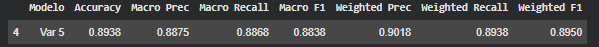

Entrenando el modelo RF Ganador (Variación 10)...


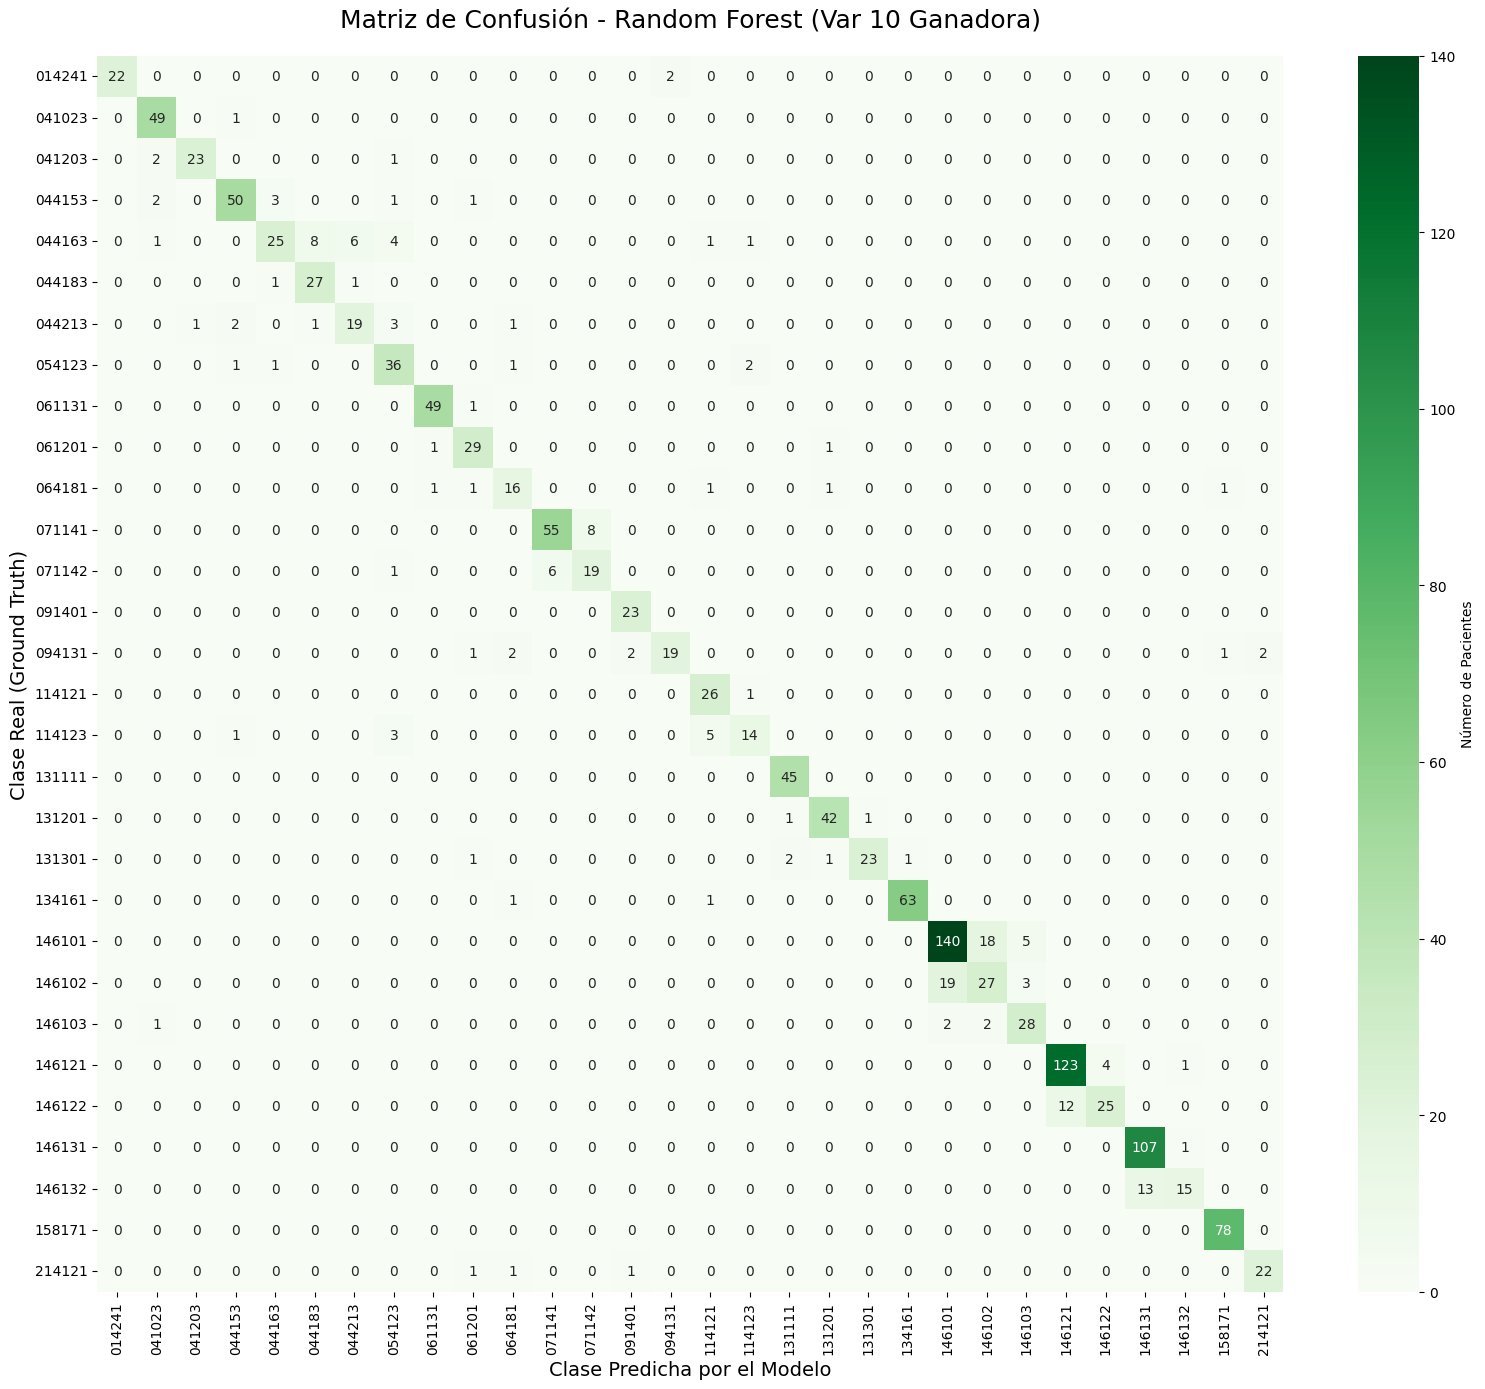

In [ ]:
#  Entrenar el modelo ganador (Variación 10)
print("Entrenando el modelo RF Ganador (Variación 10)...")
rf_ganador = RandomForestClassifier(
    n_estimators=600,
    max_depth=20,
    min_samples_leaf=2,
    random_state=42,
    class_weight='balanced',
    n_jobs=-1
)
rf_ganador.fit(X_train, y_train_enc)
pred_rf_ganador = rf_ganador.predict(X_test)

#Generar Matriz de Confusión Estética
cm_rf = confusion_matrix(y_test_enc, pred_rf_ganador)

plt.figure(figsize=(16, 14))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens', #  usamos verde para diferenciarlo del azul de mlp
            xticklabels=le.classes_, yticklabels=le.classes_,
            cbar_kws={'label': 'Número de Pacientes'})
plt.title('Matriz de Confusión - Random Forest (Var 10 Ganadora)', fontsize=18, pad=20)
plt.ylabel('Clase Real (Ground Truth)', fontsize=14)
plt.xlabel('Clase Predicha por el Modelo', fontsize=14)
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
reporte = classification_report(y_test_enc, pred_rf_ganador, output_dict=True, zero_division=0)
resultados = []
#Guardar métricas específicas
acc = reporte['accuracy']

macro_prec = reporte['macro avg']['precision']
macro_rec = reporte['macro avg']['recall']
macro_f1 = reporte['macro avg']['f1-score']

weight_prec = reporte['weighted avg']['precision']
weight_rec = reporte['weighted avg']['recall']
weight_f1 = reporte['weighted avg']['f1-score']

#Agregar a la lista de resultados
resultados.append({
    "Modelo": var['nombre'],
    "Accuracy": round(acc, 4),
    "Macro Prec": round(macro_prec, 4),
    "Macro Recall": round(macro_rec, 4),
    "Macro F1": round(macro_f1, 4),
    "Weighted Prec": round(weight_prec, 4),
    "Weighted Recall": round(weight_rec, 4),
    "Weighted F1": round(weight_f1, 4)
})
print(f"-> Listo. Accuracy: {acc:.4f} | Macro F1: {macro_f1:.4f}")

# =========================================
# MOSTRAR TABLA FINAL DE RESULTADOS
# =========================================
print("\n=== RESUMEN DETALLADO DE LAS 10 VARIACIONES DE RANDOM FOREST ===")
# Convertir a DataFrame y ordenar por Macro F1 de mayor a menor (¡Mucho mejor que por Accuracy!)
resumen_rf_df = pd.DataFrame(resultados).sort_values(by="Macro F1")

# Mostrar la tabla en Colab
display(resumen_rf_df)

-> Listo. Accuracy: 0.8713 | Macro F1: 0.8455

=== RESUMEN DETALLADO DE LAS 10 VARIACIONES DE RANDOM FOREST ===


,Modelo,Accuracy,Macro Prec,Macro Recall,Macro F1,Weighted Prec,Weighted Recall,Weighted F1
0,RF 10 (Heavy duty),0.8713,0.8578,0.8439,0.8455,0.8725,0.8713,0.868


/tmp/ipykernel_25533/3233652432.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_20_vars.values, y=top_20_vars.index, palette='viridis')


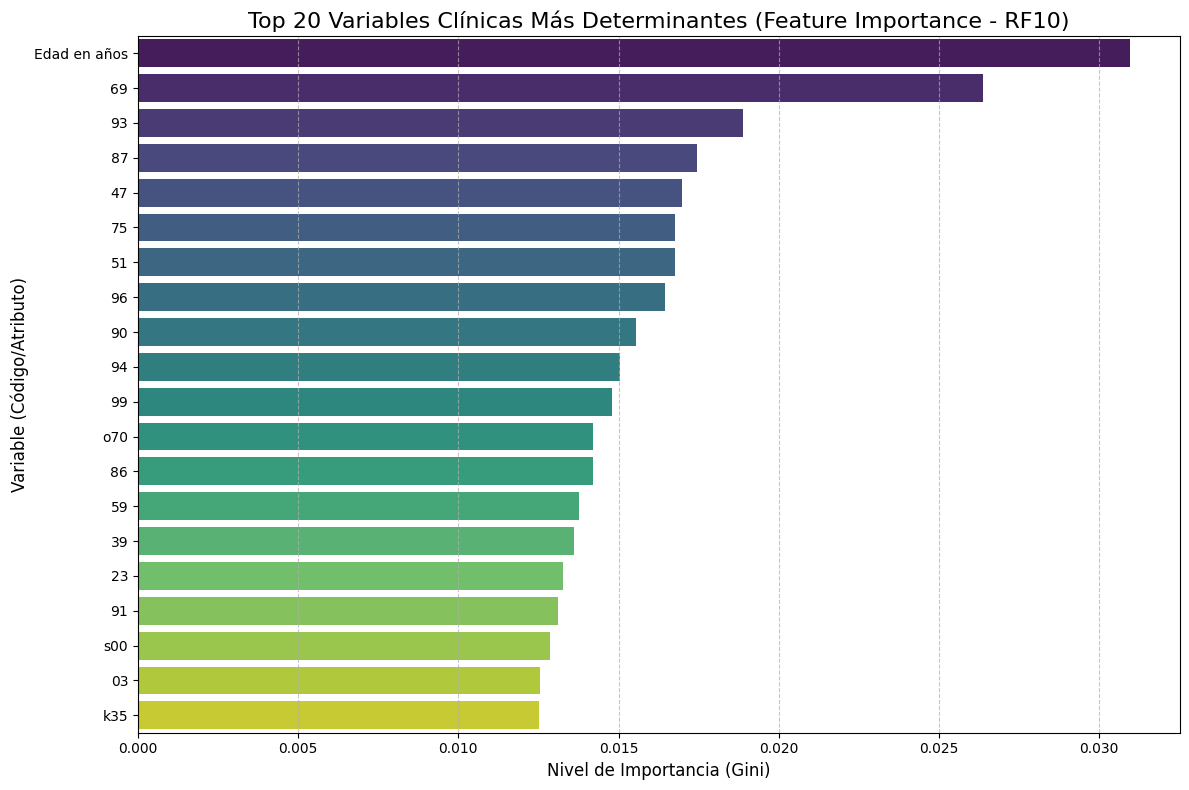

In [ ]:
#importancias del modelo ganador
importancias_ganador = pd.Series(rf_ganador.feature_importances_, index=feature_names).sort_values(ascending=False)

# top 20 de variables más importantes
top_20_vars = importancias_ganador.head(20)
#GRÁFICO
plt.figure(figsize=(12, 8))
sns.barplot(x=top_20_vars.values, y=top_20_vars.index, palette='viridis')
plt.title('Top 20 Variables Clínicas Más Determinantes (Feature Importance - RF10)', fontsize=16)
plt.xlabel('Nivel de Importancia (Gini)', fontsize=12)
plt.ylabel('Variable (Código/Atributo)', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

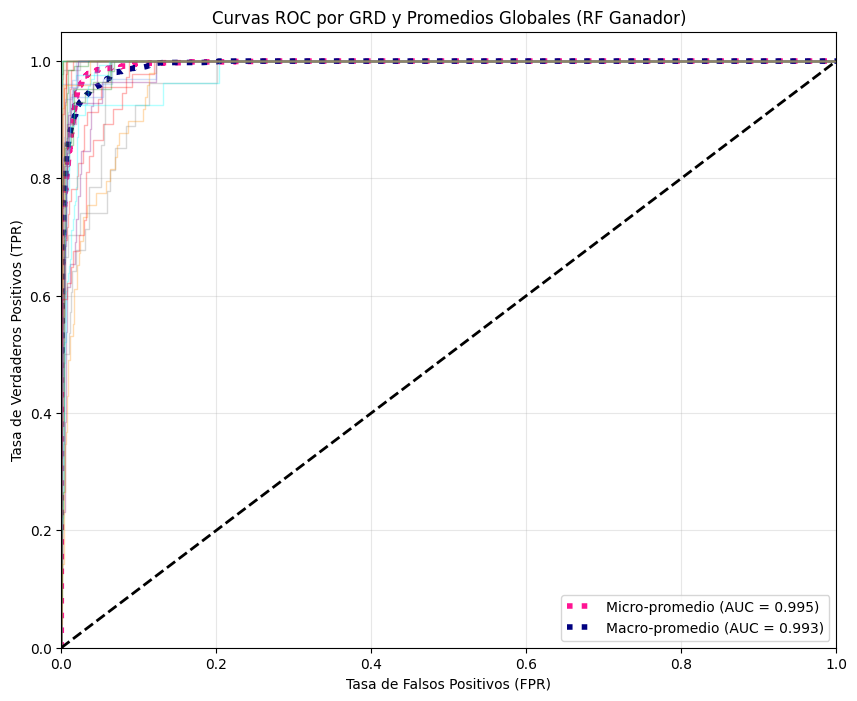

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
from itertools import cycle

# 1. Obtener las probabilidades de predicción del RF Ganador
y_pred_prob_rf = rf_ganador.predict_proba(X_test)

# 2. Binarizar las etiquetas reales (necesario para ROC multiclase)
# Asumiendo que num_classes es tu cantidad de GRDs (ej. 30)
clases_unicas = np.unique(y_test_enc)
y_test_bin = label_binarize(y_test_enc, classes=clases_unicas)
n_classes = y_test_bin.shape[1]

# 3. Calcular ROC y AUC por cada clase
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_pred_prob_rf[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# 4. Calcular Micro-promedio
fpr["micro"], tpr["micro"], _ = roc_curve(y_test_bin.ravel(), y_pred_prob_rf.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

# 5. Calcular Macro-promedio
all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))
mean_tpr = np.zeros_like(all_fpr)
for i in range(n_classes):
    mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
mean_tpr /= n_classes
fpr["macro"] = all_fpr
tpr["macro"] = mean_tpr
roc_auc["macro"] = auc(fpr["macro"], tpr["macro"])

# --- DIBUJAR EL GRÁFICO ROC ---
plt.figure(figsize=(10, 8))

# Dibujar Macro y Micro
plt.plot(fpr["micro"], tpr["micro"], label=f'Micro-promedio (AUC = {roc_auc["micro"]:.3f})',
         color='deeppink', linestyle=':', linewidth=4)
plt.plot(fpr["macro"], tpr["macro"], label=f'Macro-promedio (AUC = {roc_auc["macro"]:.3f})',
         color='navy', linestyle=':', linewidth=4)

# Dibujar las clases individuales (finitas y transparentes como en tu imagen)
colors = cycle(['aqua', 'darkorange', 'cornflowerblue', 'green', 'red', 'purple', 'grey'])
for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=1, alpha=0.3)

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curvas ROC por GRD y Promedios Globales (RF Ganador)')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

Simulando la evolución del bosque (esto puede tomar unos segundos)...


/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_forest.py:861: UserWarning: class_weight presets "balanced" or "balanced_subsample" are not recommended for warm_start if the fitted data differs from the full dataset. In order to use "balanced" weights, use compute_class_weight ("balanced", classes, y). In place of y you can use a large enough sample of the full training set target to properly estimate the class frequency distributions. Pass the resulting weights as the class_weight parameter.
  warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_forest.py:861: UserWarning: class_weight presets "balanced" or "balanced_subsample" are not recommended for warm_start if the fitted data differs from the full dataset. In order to use "balanced" weights, use compute_class_weight ("balanced", classes, y). In place of y you can use a large enough sample of the full training set target to properly estimate the class frequency distributions. Pass the resulting weights as the 

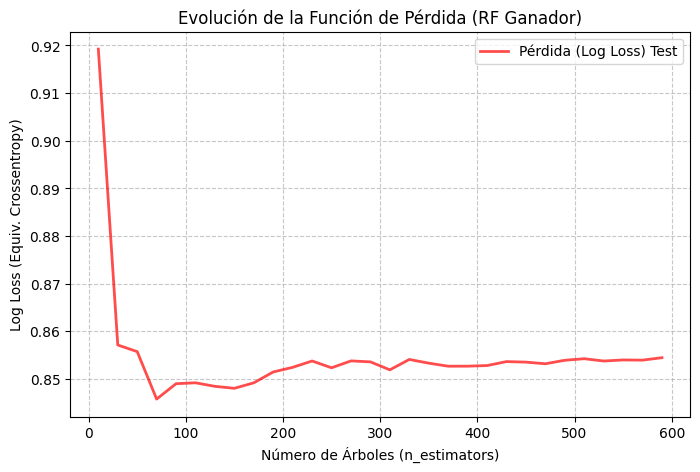

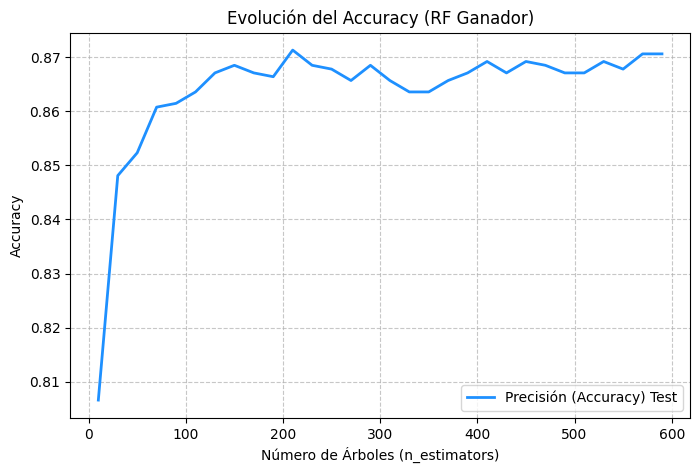

In [ ]:
#A continuación se realizarán gráficos que intentan ser similes de los gráficos de loss y accuracy de mlP
#Configuramos un modelo "clon" pero con warm_start=True para ir añadiendo árboles
rf_evolucion = RandomForestClassifier(
    n_estimators=1, # Empezamos con 1 árbol
    max_depth=20,
    min_samples_leaf=2,
    random_state=42,
    class_weight='balanced',
    n_jobs=-1,
    warm_start=True # ¡La clave para simular épocas!
)

hist_accuracy = []
hist_loss = []
lista_arboles = range(10, 610, 20) #medido cada 20 árboles hasta llegar a 600.

print("Simulando la evolución del bosque (esto puede tomar unos segundos)...")
for n_arboles in lista_arboles:
    rf_evolucion.set_params(n_estimators=n_arboles)
    rf_evolucion.fit(X_train, y_train_enc)

    pred_probs_paso = rf_evolucion.predict_proba(X_test)
    pred_clases_paso = rf_evolucion.predict(X_test)

    # Calcular métricas
    acc_paso = accuracy_score(y_test_enc, pred_clases_paso)
    loss_paso = log_loss(y_test_enc, pred_probs_paso)

    hist_accuracy.append(acc_paso)
    hist_loss.append(loss_paso)

#GRÁFICO DE PÉRDIDA (LOSS)
plt.figure(figsize=(8, 5))
plt.plot(lista_arboles, hist_loss, color='red', linewidth=2, alpha=0.7, label='Pérdida (Log Loss) Test')
plt.title('Evolución de la Función de Pérdida (RF Ganador)')
plt.xlabel('Número de Árboles (n_estimators)')
plt.ylabel('Log Loss (Equiv. Crossentropy)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()

#GRÁFICO DE PRECISIÓN (ACCURACY)
plt.figure(figsize=(8, 5))
plt.plot(lista_arboles, hist_accuracy, color='dodgerblue', linewidth=2, label='Precisión (Accuracy) Test')
plt.title('Evolución del Accuracy (RF Ganador)')
plt.xlabel('Número de Árboles (n_estimators)')
plt.ylabel('Accuracy')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()